# 07. Shape: moments of inertia and radii

**Goal.** Characterise the overall shape of a cluster — sphericity from the inertia tensor, radius of gyration, and how they evolve on melting — with ASE for a single structure and `Process` for a trajectory.

**You need.** Tutorials 01 and 05.


In [1]:
import numpy as np, matplotlib.pyplot as plt
from ase.cluster import Icosahedron, Decahedron, Octahedron

def shape_report(atoms):
    I = atoms.get_moments_of_inertia()                       # principal moments, amu Å²
    rg = np.sqrt(((atoms.positions - atoms.get_center_of_mass())**2).sum(1).mean())
    return I, I.min() / I.max(), rg

for name, s in [("Ih 561", Icosahedron("Au", 6, 4.08)), ("Dh (5,4,0)", Decahedron("Au", 5, 4, 0, 4.08)),
                ("Oct 7 cut 2", Octahedron("Au", 7, 2, 4.08)), ("rod-like Dh (3,6,0)", Decahedron("Au", 3, 6, 0, 4.08))]:
    I, ratio, rg = shape_report(s)
    print(f"{name:20s} N={len(s):4d}  I_min/I_max={ratio:.3f}  R_g={rg:5.2f} Å")

Ih 561               N= 561  I_min/I_max=1.000  R_g=10.44 Å
Dh (5,4,0)           N= 258  I_min/I_max=0.956  R_g= 7.91 Å
Oct 7 cut 2          N= 201  I_min/I_max=1.000  R_g= 7.22 Å
rod-like Dh (3,6,0)  N= 103  I_min/I_max=0.394  R_g= 6.56 Å


`I_min/I_max = 1` is a sphere-like (or cube-like) inertia ellipsoid; elongated decahedra fall well below 1.
Sapphire's `Process` computes the same three principal moments (`moi`), the radius of gyration
(`gyration`) and the *statistical radius* (`stat_radius`, the mean distance of surface atoms from the
centre) per frame.

## 7.2 Along the melting trajectory

In [2]:
import os, numpy as np, matplotlib.pyplot as plt
from Sapphire import Process
from Sapphire.Tutorials import data

work = os.path.abspath("run_AuPt") + "/"
os.makedirs(work, exist_ok=True)
movie = data.sample("AuPt", work)                 # bundled: every 20th frame (200 ps) of a 1415-atom Au80Pt20 melt
print(movie)
System = {"base_dir": work, "movie_file_name": "AuPt_sample.xyz", "extend_xyz": None, "Homo": ["Au", "Pt"], "Hetero": False,
          "Start": 0, "End": 70, "Step": 7, "Skip": 1, "UniformPDF": False, "Band": 0.05}                 # 10 frames
Quantities = {"Full": {"pdf": None, "adj": None, "nn": None, "agcn": None, "moi": None, "gyration": None, "stat_radius": None, "com": None, "comdist": None},
              "Homo": {"hocom": None, "hogyration": None, "hocomdist": None}}
proc = Process.Process(System=System, Quantities=Quantities)                                              # ~25 s
m = proc.reader().load_all(); t_ns = proc.reader().frames("nn") * 0.2

/Users/robjones/Documents/Personal/Projects/Physics/Sapphire/main/Sapphire/Tutorials/07_Shape_MoI_and_Radii/run_AuPt/AuPt_sample.xyz


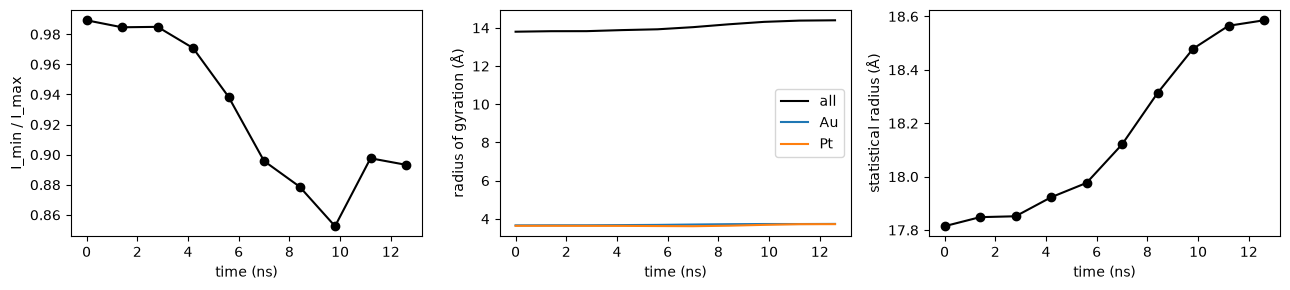

In [3]:
I = np.asarray(m["moi"])
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ax[0].plot(t_ns, I.min(1) / I.max(1), "ko-"); ax[0].set_ylabel("I_min / I_max")
ax[1].plot(t_ns, m["gyration"], "k-", label="all"); ax[1].plot(t_ns, m["hogyrationAu"], "-", label="Au"); ax[1].plot(t_ns, m["hogyrationPt"], "-", label="Pt")
ax[1].set_ylabel("radius of gyration (Å)"); ax[1].legend()
ax[2].plot(t_ns, m["stat_radius"], "ko-"); ax[2].set_ylabel("statistical radius (Å)")
for a in ax: a.set_xlabel("time (ns)")
plt.tight_layout(); plt.show()

A Pt radius of gyration *smaller* than the Au one means Pt sits preferentially inside — compare with the
mixing parameter and LAE of Tutorial 05.

## 7.3 Radial density profile

`comdist` holds every atom's distance from the centre of mass; a histogram per frame is the radial
density. Sub-species versions (`hocomdistAu`) show where each element lives.

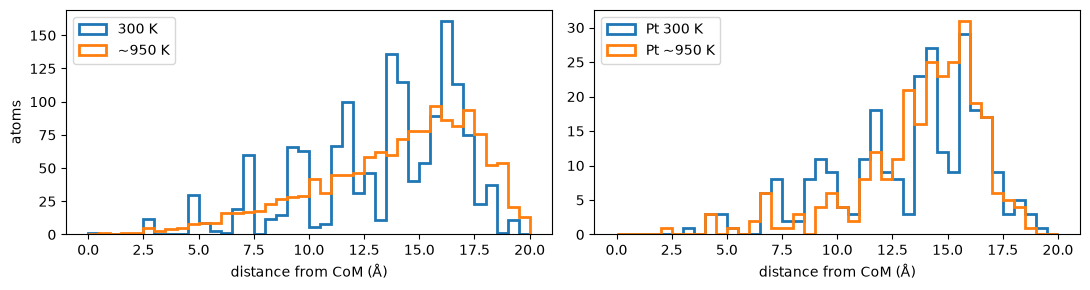

In [4]:
bins = np.linspace(0, 20, 41)
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
for f, lab in [(0, "300 K"), (len(t_ns)-1, "~950 K")]:
    ax[0].hist(m["comdist"][f], bins=bins, histtype="step", lw=2, label=lab)
    ax[1].hist(m["hocomdistPt"][f], bins=bins, histtype="step", lw=2, label="Pt " + lab)
ax[0].set_xlabel("distance from CoM (Å)"); ax[0].set_ylabel("atoms"); ax[0].legend(); ax[1].set_xlabel("distance from CoM (Å)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 7.4 Try it

* Sphericity of a *liquid* droplet fluctuates: plot `I_min/I_max` on the full 700-frame run.
* `Graphing.Plot_Funcs.cum_com` integrates the radial profile and compares it with a uniform sphere.

**Next:** *08 — Averaging over an ensemble of runs.*